# K-Nearest Neighbors (KNN) Example

This notebook demonstrates the k-Nearest Neighbors classification algorithm using the Iris dataset. It includes dataset exploration, preprocessing, model training, prediction, evaluation, and visualization.


In [9]:
# Section 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set(style="whitegrid")


## Load and Explore the Dataset

Load the Iris dataset and inspect the feature names, sample records, and class distribution.


In [10]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("Dataset shape:", X.shape)
print("Target classes:", iris.target_names)

# Display first rows and basic statistics
display(X.head())
display(X.describe())
display(y.value_counts())


Dataset shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


target
0    50
1    50
2    50
Name: count, dtype: int64

## Split Data into Training and Testing Sets

Use an 80-20 split to create training and testing subsets.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (120, 4)
Testing set size: (30, 4)


## Normalize the Features

Scale features using `StandardScaler` to ensure distance calculations are balanced across dimensions.


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature means after scaling (train):", np.round(X_train_scaled.mean(axis=0), 3))
print("Feature std after scaling (train):", np.round(X_train_scaled.std(axis=0), 3))


Feature means after scaling (train): [-0. -0.  0.  0.]
Feature std after scaling (train): [1. 1. 1. 1.]


## Train the KNN Model

Train a `KNeighborsClassifier` with `k=5` using the normalized training data.


In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("Model trained with k=5")


Model trained with k=5


## Make Predictions

Use the trained model to predict labels on the test set and show a few sample predictions.


In [14]:
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)

sample_results = pd.DataFrame({
    "true_label": y_test.values,
    "predicted_label": y_pred,
    "confidence": np.max(y_proba, axis=1),
})

display(sample_results.head(10))


,true_label,predicted_label,confidence
0,0,0,1.0
1,2,2,0.6
2,1,1,1.0
3,1,1,1.0
4,0,0,1.0
5,1,1,0.6
6,0,0,1.0
7,0,0,1.0
8,2,2,1.0
9,1,1,1.0


## Evaluate Model Performance

Compute accuracy, precision, recall, F1-score, and display a confusion matrix for the test results.


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333
F1-score: 0.9327

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Visualize Results

Visualize the confusion matrix and compare KNN performance across several values of `k`.


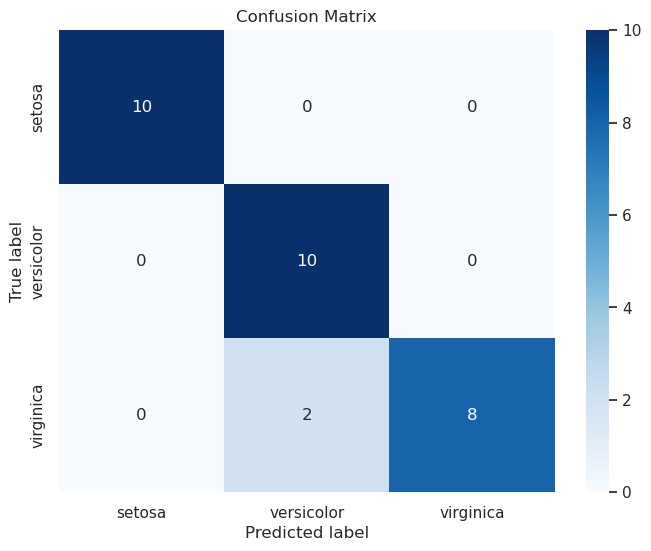

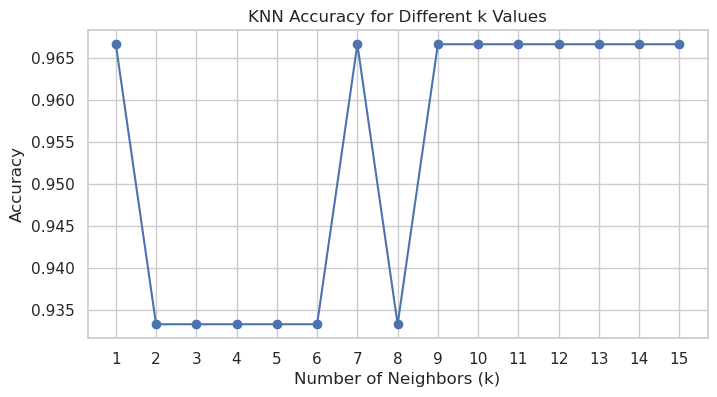

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

k_values = list(range(1, 16))
accuracy_scores = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracy_scores, marker="o")
plt.title("KNN Accuracy for Different k Values")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()
